# 07. 예측 vol × Q 추정 방식 비교

## 비교 대상 (8종 + 벤치마크 2)

| 전략 | Q 산출 방식 | 비고 |
|------|-----------|------|
| `Q_FIXED` | 06번 예측 vol 최적 Q (자동 로드) | 기준선 |
| `Q_hist` | mean(저위험 − 고위험) 60M window | 학습 기간 평균 실현수익 |
| `Q_momentum` | mean(저위험 − 고위험) 12M window | 단기 추세 |
| `Q_lambda` | Q_FIXED × clip(λ_t / λ_mean, 0.1, 3.0) | clipped λ 스케일 (항상 양수) |
| `Q_ff3` | FF3 회귀 → P·r̂ | 팩터모델 기반 |
| `Q_pi_ratio` | Q_FIXED × clip(\|P·π\| / spread_ref, 0.1, 3.0) | CAPM 스프레드 비율 |
| `Q_raw_lambda` | max(0, Q_FIXED × λ_raw / λ_mean) | raw λ 부호 자연 게이팅 |
| `Q_vol_spread` | Q_FIXED × clip(vol_spread / spread_ref, 0.1, 3.0) | 예측 vol 격차 (파이프라인 일관성) |
| **CAPM** | π = λΣw_mkt (BL 없음) | 기준선 |
| **SPY** | S&P 500 매수보유 | 시장 벤치마크 |

> Vol 소스는 **05번 예측 vol(GARCH 또는 LSTM 등 활성 모델) 단일**. Q 추정 방식만 8가지로 비교한다.
> 06번 민감도 분석에서 Sharpe 최대 Q 값을 자동 로드(`Q_FIXED`)하여 다른 7개 추정 방식과 비교.

> **Q_vol_spread 주의**: 위기 시 vol_spread가 오히려 확대되어 Q가 증가하는 역방향 위험이 있다.
> 본 노트북에서는 순수 스케일러 버전만 다루고, **레짐 하드스탑 결합 버전(Q_vol_spread_hard)은 08번**에서 처리.

> **레짐 기반 방식(Regime3, Regime+λ, Q_vol_spread_hard)은 08_Regime_Q_Portfolio에서 별도 처리**
> — 명시적 SPY 분위수 분류 인프라가 필요하므로 분리. 본 노트북은 **단일 신호로 Q를 결정**하는 방식만 비교.

## 실행 순서 의존성
```
05_VolatilityPrediction → vol_predicted.csv
06_Q_Sensitivity        → q_sensitivity_stats.csv  (Q_FIXED 자동 로드)
         ↓
07_BL_Q_Methods (예측 vol × 8Q 비교, 비-레짐)
         ↓
08_Regime_Q_Portfolio (레짐 기반 Q 전략)
```

## 기간
- **2010-01 ~ 2024-12** (180개월) — 15년 OOS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
import platform
from pathlib import Path
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize
from bl_utils import *  # 공통 BL/Q/성과 유틸리티

warnings.filterwarnings('ignore')
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
OUT_DIR  = BASE_DIR / 'outputs' / '07_BL_Q_Methods'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 파라미터 ────────────────────────────────────────────────
TRAIN_WINDOW    = 60
TAU             = 0.1
PCT_GROUP       = 0.30
START_PRED      = '2010-01-01'
END_PRED     = '2024-12-31'  # 15년 OOS 종료
MOMENTUM_WINDOW = 12
LAM_MEAN        = 2.5

# ── 06a 예측 vol expanding-window Q* 자동 로드 (GARCH/LSTM 모델 무관) ─────────
EXP_LOG = BASE_DIR / 'outputs' / '06a_Q_Sensitivity_Predicted' / 'q_expanding_pred_log.csv'
assert EXP_LOG.exists(), '06a_Q_Sensitivity_Predicted.ipynb 먼저 실행해 expanding log를 생성하세요'
_log = pd.read_csv(EXP_LOG, parse_dates=['date'], index_col='date')
Q_PRED = float(_log['q_used'].iloc[-1])
print(f'Q_PRED (06a expanding-window 마지막 Q*) = {Q_PRED}')

# ── 데이터 로드 ──────────────────────────────────────────────
panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv', parse_dates=['date'])
panel = panel.set_index(['date', 'ticker'])

all_dates  = panel.index.get_level_values('date').unique().sort_values()
pred_dates = all_dates[(all_dates >= START_PRED) & (all_dates <= END_PRED)]

ret_pivot  = panel['ret_1m'].unstack('ticker')
spy_series = panel['spy_ret'].groupby(level='date').first()
rf_series  = panel['rf_1m'].groupby(level='date').first()

print(f'패널: {panel.shape}')
print(f'예측 기간: {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')

Q_PRED (06a expanding-window 마지막 Q*) = 0.002
패널: (108135, 11)
예측 기간: 2010-01-31 ~ 2024-12-31 (180개월)


In [2]:
# ── FF3 팩터 로드 ─────────────────────────────────────────────
FF3_PATH = DATA_DIR / 'ff3_monthly.csv'
if FF3_PATH.exists():
    ff3 = pd.read_csv(FF3_PATH, index_col='date', parse_dates=True)
    print(f'FF3 로드: {ff3.shape}')
else:
    print('FF3 다운로드 중...')
    ff3 = download_ff3()
    ff3.to_csv(FF3_PATH)
    print(f'FF3 저장: {ff3.shape}')

# ── GARCH 예측 vol 로드 ──────────────────────────────────────
PRED_PATH = DATA_DIR / 'vol_predicted.csv'
assert PRED_PATH.exists(), '05_VolatilityPrediction.ipynb 먼저 실행해 vol_predicted.csv 생성하세요'
vol_pred_df    = pd.read_csv(PRED_PATH, parse_dates=['date'])
vol_pred_pivot = vol_pred_df.set_index(['date', 'ticker'])['vol_pred'].unstack('ticker')
print(f'GARCH 예측 로드: {vol_pred_pivot.shape}')

FF3 로드: (1196, 4)
GARCH 예측 로드: (180, 596)


In [3]:
# ── Walk-forward: 예측 vol × 8Q 비교 ──────────────────────────
results = {f'Q_{m}': [] for m in ['FIXED', 'hist', 'momentum', 'lambda', 'ff3',
                                    'pi_ratio', 'raw_lambda', 'vol_spread']}
results['CAPM'] = []
results['SPY']  = []
q_log = []

# expanding median 누적기 (look-ahead bias 방지: 사용 후 추가)
pi_spread_history  = []   # π_ratio용: |P·π|
vol_spread_history = []   # vol_spread용: vol_high − vol_low

print(f'Walk-forward: {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')
print(f'  Q_FIXED = Q_PRED = {Q_PRED}  (월 {Q_PRED*100:.1f}%  |  연 {Q_PRED*12*100:.1f}%)')

for i, pred_date in enumerate(pred_dates):
    if (i + 1) % 12 == 0:
        print(f'  {pred_date.date()} ({i+1}/{len(pred_dates)})')
    try:
        if pred_date not in vol_pred_pivot.index:
            continue

        month_base = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'log_mcap', 'ret_1m'])
        if len(month_base) < 30:
            continue

        pred_vol = vol_pred_pivot.loc[pred_date].reindex(month_base.index)
        month_df = month_base.copy()
        month_df['vol_use'] = pred_vol
        month_df = month_df.dropna(subset=['vol_use'])
        if len(month_df) < 20:
            continue

        idx         = all_dates.get_loc(pred_date)
        train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]
        rf_s        = rf_series.reindex(train_dates)
        spy_s       = spy_series.reindex(train_dates)
        spy_excess  = (spy_s - rf_s).mean()
        sigma2_mkt  = spy_s.var()
        lam_raw     = spy_excess / sigma2_mkt if sigma2_mkt > 0 else 0.0  # clip 전 raw λ

        universe  = month_df.index.tolist()
        thresh    = int(len(train_dates) * 0.7)
        ret_slice = (ret_pivot.reindex(index=train_dates, columns=universe)
                              .dropna(axis=1, thresh=thresh)
                              .fillna(0))
        valid_tix = ret_slice.columns.tolist()
        if len(valid_tix) < 20:
            continue

        month_df = month_df.reindex(valid_tix)
        Sigma    = compute_sigma(ret_slice)
        mcap     = np.exp(month_df['log_mcap'])
        w_mkt    = (mcap / mcap.sum()).reindex(valid_tix).fillna(0)
        pi, lam  = compute_pi(Sigma, w_mkt, spy_excess, sigma2_mkt)

        P     = build_P(month_df['vol_use'], mcap, pct=PCT_GROUP)
        P     = P.reindex(valid_tix).fillna(0)
        omega = compute_omega(P, Sigma, TAU)

        # π_ratio용 현재 |P·π| + expanding median으로 spread_ref 결정
        pi_spread_t   = abs(float(P.values @ pi.values))
        pi_spread_ref = float(np.median(pi_spread_history)) if pi_spread_history else max(pi_spread_t, 1e-8)

        # vol_spread용 현재 격차 + expanding median
        vol_pred_aligned = month_df['vol_use'].reindex(valid_tix)
        vol_spread_t     = float(vol_pred_aligned[P < 0].mean() - vol_pred_aligned[P > 0].mean())
        vol_spread_ref   = float(np.median(vol_spread_history)) if vol_spread_history else max(vol_spread_t, 1e-8)

        # ── Q 8종 계산 ──────────────────────────────────────
        q_vals = {
            'FIXED':       Q_PRED,
            'hist':        compute_Q_hist(P, ret_slice),
            'momentum':    compute_Q_momentum(P, ret_slice, window=MOMENTUM_WINDOW),
            'lambda':      compute_Q_lambda(lam, Q_PRED, lam_mean=LAM_MEAN),
            'ff3':         compute_Q_ff3(P, ret_slice, ff3.reindex(train_dates), rf_s),
            'pi_ratio':    compute_Q_pi_ratio(P, pi, Q_PRED, pi_spread_ref),
            'raw_lambda':  compute_Q_raw_lambda(lam_raw, Q_PRED, lam_mean=LAM_MEAN),
            'vol_spread':  compute_Q_vol_spread(P, vol_pred_aligned, Q_PRED, vol_spread_ref),
        }
        q_log.append({'date': pred_date, 'lam_raw': lam_raw,
                      'pi_spread': pi_spread_t, 'vol_spread': vol_spread_t,
                      **{f'Q_{k}': v for k, v in q_vals.items()}})
        pi_spread_history.append(pi_spread_t)    # 사용 후 추가
        vol_spread_history.append(vol_spread_t)

        next_date  = all_dates[idx + 1] if idx + 1 < len(all_dates) else None
        actual_ret = (ret_pivot.loc[next_date].reindex(valid_tix).fillna(0)
                            if next_date is not None
                            else month_df['fwd_ret_1m'].reindex(valid_tix).fillna(0))

        for q_name, q_val in q_vals.items():
            mu_BL = black_litterman(pi, Sigma, P, q_val, omega, TAU)
            w_bl  = optimize_portfolio(mu_BL, Sigma, lam)
            results[f'Q_{q_name}'].append({'date': pred_date, 'ret': float(w_bl @ actual_ret)})

        # 벤치마크: CAPM (BL 없음, π를 그대로 사용)
        w_capm = optimize_portfolio(pi, Sigma, lam)
        results['CAPM'].append({'date': pred_date, 'ret': float(w_capm @ actual_ret)})
        # SPY
        results['SPY'].append({'date': pred_date, 'ret': float(spy_series.get(next_date, np.nan))})

    except Exception as e:
        if i < 5:
            print(f'  [에러] {pred_date.date()}: {e}')

# 결과 시계열 정리
ret_series = {}
for k, v in results.items():
    if v:
        ret_series[k] = pd.DataFrame(v).set_index('date')['ret'].dropna()

q_df = pd.DataFrame(q_log).set_index('date') if q_log else pd.DataFrame()
print(f'\n완료')
for k, s in ret_series.items():
    print(f'  {k}: {len(s)}개월')

Walk-forward: 2010-01-31 ~ 2024-12-31 (180개월)
  Q_FIXED = Q_PRED = 0.002  (월 0.2%  |  연 2.4%)


  2010-12-31 (12/180)


  2011-12-31 (24/180)


  2012-12-31 (36/180)


  2013-12-31 (48/180)


...

  2021-12-31 (144/180)


  2022-12-31 (156/180)


  2023-12-31 (168/180)


  2024-12-31 (180/180)



완료
  Q_FIXED: 180개월
  Q_hist: 180개월
  Q_momentum: 180개월
  Q_lambda: 180개월
  Q_ff3: 180개월
  Q_pi_ratio: 180개월
  Q_raw_lambda: 180개월
  Q_vol_spread: 180개월
  CAPM: 180개월
  SPY: 180개월


In [4]:
# ── 성과 분석 ────────────────────────────────────────────────
rf_monthly = panel['rf_1m'].groupby(level='date').first()

ORDER = ['Q_FIXED', 'Q_hist', 'Q_momentum', 'Q_lambda', 'Q_ff3',
         'Q_pi_ratio', 'Q_raw_lambda', 'Q_vol_spread', 'CAPM', 'SPY']

stats_list = [performance(ret_series[k], rf_monthly, k) for k in ORDER if k in ret_series]
stats_df   = pd.DataFrame(stats_list).set_index('label')

disp = stats_df.copy()
for col in ['ann_ret', 'ann_vol', 'cum_ret', 'mdd']:
    disp[col] = disp[col].map('{:.2%}'.format)
for col in ['sharpe', 'calmar']:
    disp[col] = disp[col].map('{:.3f}'.format)
disp.columns = ['연환산수익률', '연환산변동성', 'Sharpe', 'Calmar', '누적수익률', 'MDD']

print('=' * 80)
print('예측 vol × Q 추정 방식 성과 비교 (2010-01 ~ 2024-12)')
print('=' * 80)
print(disp.to_string())

# Q_FIXED 대비 Sharpe / MDD 차이
base_sh  = stats_df.loc['Q_FIXED', 'sharpe']
base_mdd = stats_df.loc['Q_FIXED', 'mdd']
print(f'\nvs Q_FIXED (Sharpe {base_sh:.3f} | MDD {base_mdd:.2%}):')
for name in ORDER:
    if name in stats_df.index and name != 'Q_FIXED':
        ds = stats_df.loc[name, 'sharpe'] - base_sh
        dm = stats_df.loc[name, 'mdd']    - base_mdd
        print(f'  {name:14s}  ΔSharpe {ds:+.3f}   ΔMDD {dm:+.2%}')

예측 vol × Q 추정 방식 성과 비교 (2010-01 ~ 2024-12)
              연환산수익률  연환산변동성 Sharpe Calmar    누적수익률      MDD
label                                                       
Q_FIXED       12.66%  12.14%  0.945  0.657  493.60%  -19.28%
Q_hist        12.20%  12.79%  0.863  0.618  447.30%  -19.74%
Q_momentum    10.36%  17.58%  0.523  0.213  271.82%  -48.61%
Q_lambda      12.71%  12.12%  0.951  0.713  498.46%  -17.84%
Q_ff3         12.36%  18.58%  0.602  0.237  388.21%  -52.11%
Q_pi_ratio    12.69%  12.16%  0.946  0.687  495.76%  -18.46%
Q_raw_lambda  12.82%  12.16%  0.957  0.719  507.80%  -17.84%
Q_vol_spread  12.60%  12.14%  0.940  0.652  487.80%  -19.33%
CAPM          13.78%  14.74%  0.855  0.613  564.80%  -22.46%
SPY           14.45%  14.51%  0.916  0.604  638.27%  -23.93%

vs Q_FIXED (Sharpe 0.945 | MDD -19.28%):
  Q_hist          ΔSharpe -0.083   ΔMDD -0.46%
  Q_momentum      ΔSharpe -0.422   ΔMDD -29.33%
  Q_lambda        ΔSharpe +0.006   ΔMDD +1.43%
  Q_ff3           ΔSharpe -0.343   ΔMDD -

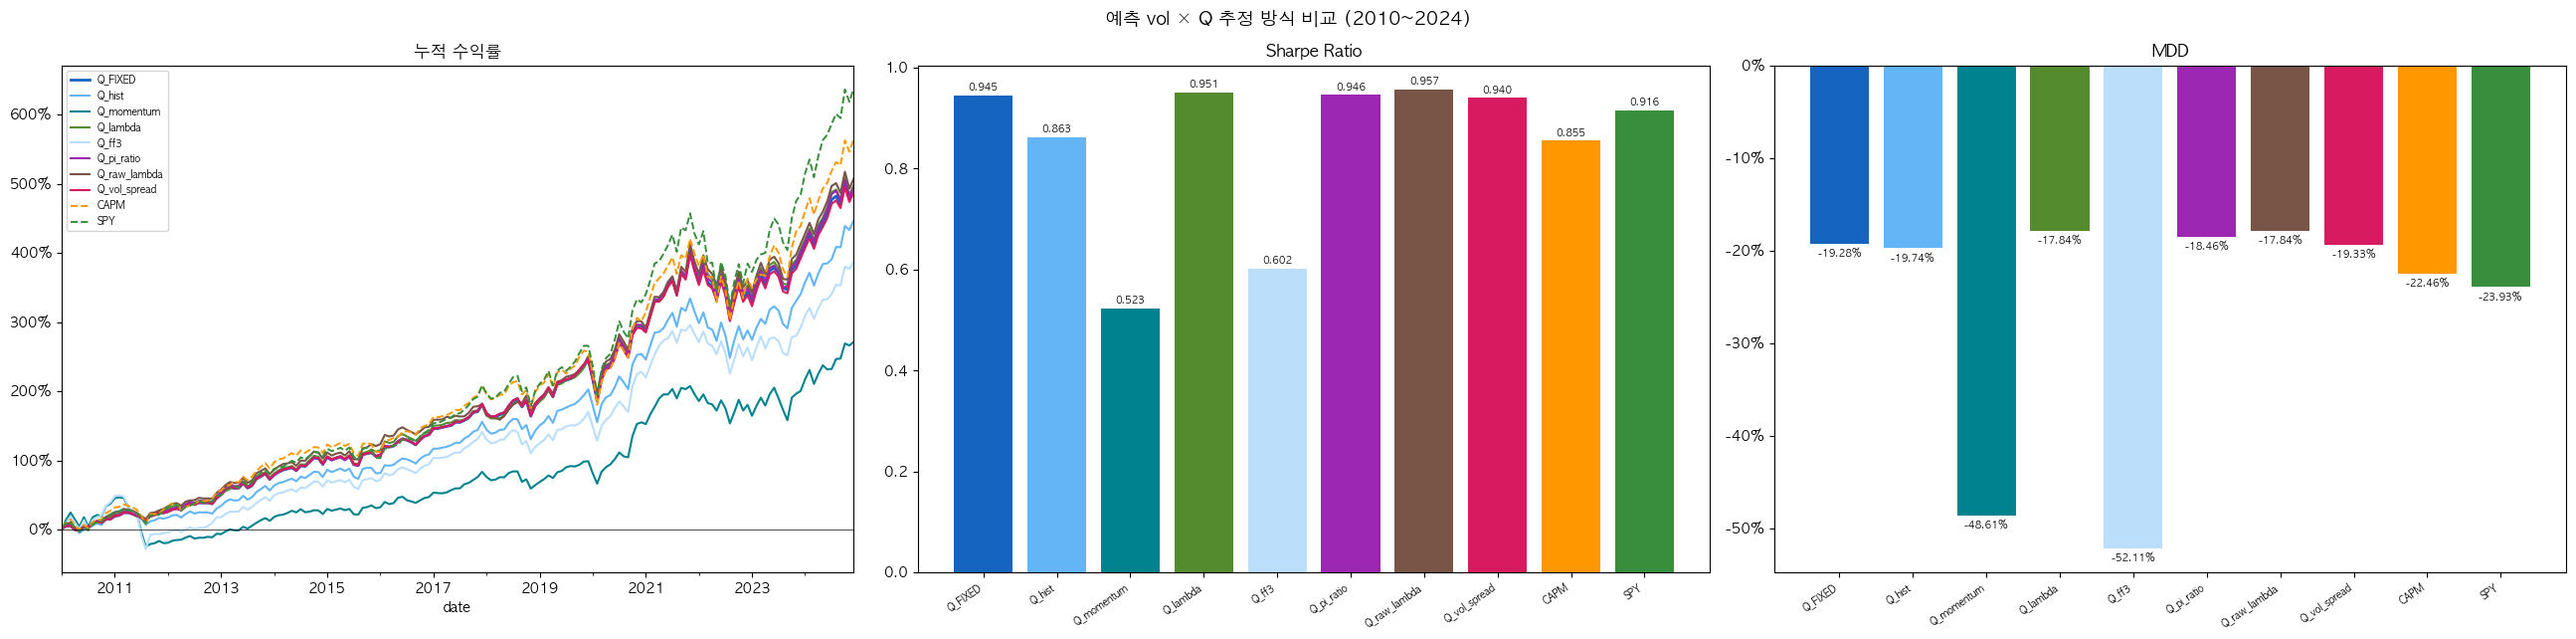

저장 완료


In [5]:
# ── 시각화 ───────────────────────────────────────────────────
STYLE = {
    'Q_FIXED':       ('#1565C0', '-',  2.0),
    'Q_hist':        ('#64B5F6', '-',  1.5),
    'Q_momentum':    ('#00838F', '-',  1.5),
    'Q_lambda':      ('#558B2F', '-',  1.5),
    'Q_ff3':         ('#BBDEFB', '-',  1.5),
    'Q_pi_ratio':    ('#9C27B0', '-',  1.5),
    'Q_raw_lambda':  ('#795548', '-',  1.5),
    'Q_vol_spread':  ('#D81B60', '-',  1.5),
    'CAPM':          ('#FF9800', '--', 1.4),
    'SPY':           ('#388E3C', '--', 1.4),
}

fig, axes = plt.subplots(1, 3, figsize=(26, 6.5))
fig.suptitle('예측 vol × Q 추정 방식 비교 (2010~2024)', fontsize=13, fontweight='bold')

# ① 누적 수익률
ax = axes[0]
for k in ORDER:
    if k not in ret_series:
        continue
    color, ls, lw = STYLE[k]
    cum = (1 + ret_series[k]).cumprod() - 1
    cum.plot(ax=ax, label=k, color=color, linestyle=ls, linewidth=lw)
ax.set_title('누적 수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=7)
ax.axhline(0, color='black', linewidth=0.5)

# ② Sharpe
ax = axes[1]
keys    = [s['label'] for s in stats_list]
sharpes = [s['sharpe'] for s in stats_list]
colors  = [STYLE[k][0] for k in keys]
bars = ax.bar(range(len(keys)), sharpes, color=colors)
ax.set_xticks(range(len(keys)))
ax.set_xticklabels(keys, rotation=35, ha='right', fontsize=7)
ax.set_title('Sharpe Ratio')
ax.axhline(0, color='black', linewidth=0.5)
for bar, val in zip(bars, sharpes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

# ③ MDD
ax = axes[2]
mdds = [s['mdd'] for s in stats_list]
bars = ax.bar(range(len(keys)), mdds, color=colors)
ax.set_xticks(range(len(keys)))
ax.set_xticklabels(keys, rotation=35, ha='right', fontsize=7)
ax.set_title('MDD')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.axhline(0, color='black', linewidth=0.5)
for bar, val in zip(bars, mdds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.005,
            f'{val:.2%}', ha='center', va='top', fontsize=7)

plt.tight_layout()
plt.savefig(OUT_DIR / 'q_methods_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 결과 저장
pd.DataFrame(ret_series).to_csv(DATA_DIR / 'q_methods_returns.csv')
stats_df.to_csv(OUT_DIR / 'q_methods_stats.csv')
if not q_df.empty:
    q_df.to_csv(OUT_DIR / 'q_methods_log.csv')
print('저장 완료')